# Resolución problema MMM a partir de su matriz QUBO

In [ ]:
#pip install pulser pulser-simulation
from bloqade.analog import start, cast, load, save
import os
import matplotlib.pyplot as plt
from bokeh.io import output_notebook
from bloqade.analog.atom_arrangement import ListOfLocations, Square
from bloqade.analog import piecewise_linear, cast
from bloqade.analog.atom_arrangement import ListOfLocations, Lieb, Square, Chain, Honeycomb, Kagome, Triangular, Rectangular
import numpy as np
from IPython.display import display, HTML
from bokeh.io import output_notebook
output_notebook()

import matplotlib.pyplot as plt
import pulser
import pulser_simulation
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform
import matplotlib.colors as mcolors
import time


c:\Users\javip\Documents\Códigos_TFG\Codigo_tfg\.venv\Lib\site-packages\bloqade\analog\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


Loading BokehJS ...

# Definición de funciones para la resolución del grafo
1. `resolucion_clasica`: Obtiene la solución a lo bruto de forma clásica
2. `construir_geometria`: Establece la geometrías que codifica la matriz QUBO dada. Usa el algoritmo clásico Nelder-Mead
3. `resolver_qubo`: Emula el ordenador cuántico aportando la solución

In [2]:
    # Obtenemos la solución clásica por fuerza bruta
    def resolucion_clasica(Q_exacta, print_resultados = False):
        """
        Resuelve un problema QUBO por fuerza bruta (enumeración exhaustiva).

        Parámetros
        ----------
        Q       : array-like – Matriz QUBO.
        verbose : bool       – Si True, imprime las mejores soluciones.

        Retorna
        -------
        sort_zipped : list[(str, float)] – Todos los bitstrings ordenados por coste.
        """
        Q_exacta = np.array(Q_exacta)

        bitstrings = [np.binary_repr(i, len(Q_exacta)) for i in range(2 ** len(Q_exacta))]
        costs = []
        # this takes exponential time with the dimension of the QUBO
        for b in bitstrings:
            z = np.array(list(b), dtype=int)
            cost = z @ Q_exacta @ z
            costs.append(cost)
        zipped = zip(bitstrings, costs)
        sort_zipped = sorted(zipped, key=lambda x: x[1])

        if print_resultados:
            print(f"---Solución clásica: \n {sort_zipped[:6]} \n")

        return sort_zipped
    # Ejecución de la función 
    #sort_zipped = resolucion_clasica(Q_exacta)


    # Determinamos la geometría de los átomos para Q
    def construir_geometria(Q, seed=0, tol=1e-6, maxiter=200000, plot=False, x0_func=None):
        """
        Optimiza las coordenadas atómicas para que las interacciones Rydberg
        reproduzcan la matriz QUBO, y construye la geometría de Bloqade.

        Parámetros
        ----------
        Q       : array-like – Matriz QUBO (simétrica).
        seed    : int        – Semilla para reproducibilidad.
        tol     : float      – Tolerancia del optimizador Nelder-Mead.
        maxiter : int        – Máximo de iteraciones.
        plot    : bool       – Si True, dibuja el registro Pulser y la geometría Bloqade.

        Retorna
        -------
        geometria : bloqade Program – Geometría lista para montar el programa.
        coords    : np.ndarray      – Coordenadas optimizadas (n×2).
        """
        Q = np.array(Q)
        device = pulser.DigitalAnalogDevice

        def evaluate_mapping(new_coords):
            new_coords = np.reshape(new_coords, (len(Q), 2))
            new_Q = squareform(device.interaction_coeff / pdist(new_coords) ** 6)
            return np.linalg.norm(new_Q - Q)

        # Por si queremos cambiar el x0:
        if x0_func is not None:
            x0 = x0_func(A, Q)
        else:
            np.random.seed(seed)
            x0 = np.random.random(len(Q) * 2)

        #if random_x0 == True:
        #    np.random.seed(seed)
        #    x0 = np.random.random(len(Q) * 2)
        #elif random_x0 == False:
        #    C6 = 2 * np.pi * 862690
        #    d_init = (C6 / A) ** (1/6)
        #    x0 = np.array([[i * d_init, 0.0] for i in range(len(Q))]).flatten() #Esto es para colocar los átomos en línea, con la distancia inicial d_init

        res = minimize(
            evaluate_mapping,
            x0,
            method="Nelder-Mead",
            tol=tol,
            options={"maxiter": maxiter, "maxfev": None},
        )

        coords = np.reshape(res.x, (len(Q), 2))

        if plot:
            # Visualización Pulser
            #coord_dict = {f"q{i}": coord for i, coord in enumerate(coords)}
            #reg = pulser.Register(coord_dict)
            #reg.draw(
            #    blockade_radius=device.rydberg_blockade_radius(1),
            #    draw_graph=False,
            #    draw_half_radius=True,
            #)
            coord_dict = {f"e{i}": coord for i, coord in enumerate(coords)}
            reg = pulser.Register(coord_dict)
            # Radio de bloqueo operativo: el omega_max que se usa en resolver_qubo
            omega_max = 0.9 * np.min(-np.diag(Q))
            reg.draw(
                blockade_radius=device.rydberg_blockade_radius(omega_max),
                draw_graph=False,
                draw_half_radius=True,
            )
            print(f"Coordenadas optimizadas:\n{coords}")

        # Construcción Bloqade
        coordenadas = [tuple(pt) for pt in coords.tolist()]
        geometria = start.add_position(coordenadas)

        if plot:
            geometria.show()

        return geometria, coords
    # Ejecución de la función 
    #geometria, coords = construir_geometria(Q)


    def resolver_qubo(Q, geometria, sort_zipped, A, B, C,
                        sweep_time=11.0, plot=False, n_shots=1000):
        """
        Ejecuta la simulación de átomos neutros para un problema QUBO dado.

        Parámetros
        ----------
        Q             : array-like  – Matriz QUBO.
        geometria     : Register     – Geometría de átomos (Bloqade).
        sort_zipped   : list[(str, float)] – Soluciones clásicas ordenadas (bitstring, energía).
        A, B, C       : float        – Coeficientes QUBO (solo para etiquetas).
        omega_max     : float        – Amplitud máxima de la frecuencia de Rabi.
        sweep_time    : float        – Tiempo de evolución adiabática [µs].
        plot          : bool         – Si True, muestra el histograma.
        n_shots       : int          – Número de disparos de la simulación.
        sweep_time    : float        – Tiempo de evolución adiabática [µs].
        plot          : bool         – Si True, muestra el histograma.

        Retorna
        -------
        prob_exito    : float        – Probabilidad de medir la solución correcta.
        counts_str    : dict         – {bitstring: conteos}.
        """
        # ── PASO 1: Detunings locales desde la diagonal de Q ──
        Q = np.array(Q)
        delta_local = -np.diag(Q)
        delta_end   = np.max(delta_local)
        escalas     = (delta_local / delta_end).tolist()

        # ── PASO 2: Parámetros de pulso ──
        omega_max = 0.9 * np.min(np.abs(delta_local))
        sweep_time= sweep_time
        durations             = [0.8, sweep_time, 0.8]
        rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
        rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]

        # ── PASO 3: Simulación ──
        prog = (
            geometria
            .rydberg.rabi.amplitude.uniform.piecewise_linear(durations, rabi_amplitude_values)
            .detuning.scale(escalas).piecewise_linear(durations, rabi_detuning_values)
        )
        emu_prog = prog.bloqade.python().run(shots=n_shots)
        report   = emu_prog.report()
        if plot:
            report.show()


        # ── PASO 4: Análisis ──
        counts = report.counts()[0]
        counts_str = {
            "".join(str(b) for b in estado): n
            for estado, n in counts.items()
        }

        energia_minima   = sort_zipped[0][1]
        soluciones_validas = [b for b, e in sort_zipped if e == energia_minima]

        exitos     = sum(counts_str.get(s, 0) for s in soluciones_validas)
        prob_exito = exitos / n_shots

        # ── PASO 5: Resultados ──
        if plot:
            print(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
            print(f"  Soluciones válidas: {soluciones_validas}  (E = {energia_minima:.3f})")
            print(f"  Conteos solución:   {exitos} / {n_shots}")
            counts_ordenado = dict(sorted(counts_str.items(), key=lambda x: x[1], reverse=True))
            colores = ["r" if b in soluciones_validas else "steelblue" for b in counts_ordenado]
            plt.figure(figsize=(12, 5))
            plt.bar(counts_ordenado.keys(), counts_ordenado.values(), color=colores, width=0.5)
            plt.xlabel("Bitstrings")
            plt.ylabel("Conteos")
            plt.title(f"A={A}, B={B}, C={C}  →  P(éxito) = {prob_exito*100:.2f}%")
            plt.xticks(rotation=90, fontsize=7)
            plt.tight_layout()
            plt.show()

        return prob_exito, counts_str
    # Ejecución de la función 
    #prob, counts = resolver_qubo(Q, geometria, sort_zipped, A, B, C)

## Generar gráficas señales para el informe

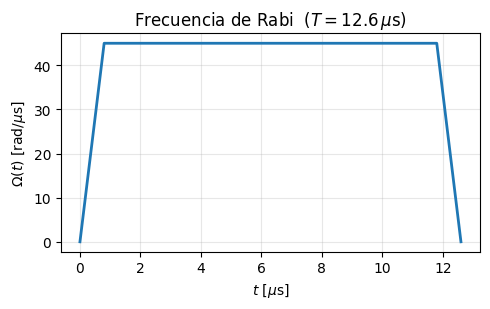

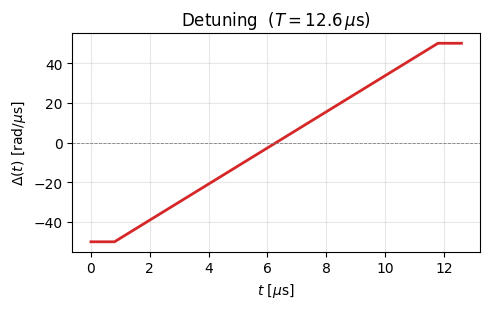

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros del pulso ---
sweep_time = 11.0          # µs, duración del tramo central
durations = [0.8, sweep_time, 0.8]
T_total = sum(durations)   # duración total del pulso

# Valores de ejemplo (rad/µs); ajusta si quieres reflejar otro caso
delta_end  = 50.0
omega_max  = 0.9 * delta_end

rabi_amplitude_values = [0.0, omega_max, omega_max, 0.0]
rabi_detuning_values  = [-delta_end, -delta_end, delta_end, delta_end]

# Eje temporal acumulado
t = np.concatenate(([0.0], np.cumsum(durations)))

# --- Figura 1: Frecuencia de Rabi ---
fig1, ax1 = plt.subplots(figsize=(5, 3.2))
ax1.plot(t, rabi_amplitude_values, color="tab:blue", lw=2)
ax1.set_xlabel(r"$t$ [$\mu$s]")
ax1.set_ylabel(r"$\Omega(t)$ [rad/$\mu$s]")
ax1.set_title(rf"Frecuencia de Rabi  ($T = {T_total:.1f}\,\mu$s)")
ax1.grid(alpha=0.3)
fig1.tight_layout()
fig1.savefig("pulso_rabi.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Figura 2: Detuning ---
fig2, ax2 = plt.subplots(figsize=(5, 3.2))
ax2.plot(t, rabi_detuning_values, color="tab:red", lw=2)
ax2.set_xlabel(r"$t$ [$\mu$s]")
ax2.set_ylabel(r"$\Delta(t)$ [rad/$\mu$s]")
ax2.set_title(rf"Detuning  ($T = {T_total:.1f}\,\mu$s)")
ax2.axhline(0, color="gray", lw=0.6, ls="--")
ax2.grid(alpha=0.3)
fig2.tight_layout()
fig2.savefig("pulso_detuning.png", dpi=200, bbox_inches="tight")
plt.show()

# Definición del grafo (matriz Q)
Distingo entre `Q` y `Q_exacta` porque la interacción entre aristas separadas por más de un nodo a veces altera la resolución del problema

### Grafo $P_4$

In [ ]:
#Grafo P_4 (cadena de 4 nodos)

A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P4")

Q_func_P4 = lambda A, B, C: np.array(
    [[-2*B+C, A+2*B, 0      ],
     [0,      -3*B+C, A+2*B ],
     [0,       0,     -2*B+C]]
)
Q_func = Q_func_P4

Q_exacta_func_P4 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B],
    [0,      -3*B+C, A+2*B],
    [0,       0,     -2*B+C]
])
Q_exacta_func = Q_exacta_func_P4

def x0_func_P4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()


### $P_5$

In [ ]:
A_solucion=50
B_solucion=0.8*A_solucion
C_solucion=0.5*A_solucion

nombre_grafo = str("P5")

Q_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
Q_func = Q_func_P5

Q_exacta_func_P5 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0     ],
    [0,      -3*B+C, A+2*B, 0     ],
    [0,       0,    -3*B+C, A+2*B ],
    [0,       0,     0,    -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P5

def x0_func_P5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([[i * d, 0.0] for i in range(len(Q))]).flatten()

### $P_5 \ modificado$ 

In [ ]:
A_solucion=20
B_solucion=0.5*A_solucion
C_solucion=0.1*A_solucion

nombre_grafo = str("P5 modificado")

Q_func_P5mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -4*B+C, A+2*B, 0,      A+2*B ],
    [0,       0,    -4*B+C, A+2*B,  A+2*B ],
    [0,       0,     0,    -2*B+C,  0     ],
    [0,       0,     0,     0,     -3*B+C ]
])
Q_func = Q_func_P5mod


Q_exacta_func_P5mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      B     ],
    [0,      -4*B+C, A+2*B, B,      A+2*B ],
    [0,       0,    -4*B+C, A+2*B,  A+2*B ],
    [0,       0,     0,    -2*B+C,  B     ],
    [0,       0,     0,     0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P5mod


#C6 = 2 * np.pi * 862690
#d_init = (C6 / A) ** (1/6)

def x0_func_P5mod(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [1.5 * d, d  ],  # e4
    ]).flatten()

### $P_6$

In [ ]:
A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P6")

Q_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, 0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0     ],
    [0,       0,    -3*B+C, A+2*B,  0     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
Q_func = Q_func_P6

Q_exacta_func_P6 = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0    ],
    [0,      -3*B+C, A+2*B, B,      0     ],
    [0,       0,    -3*B+C, A+2*B,  B     ],
    [0,       0,     0,    -3*B+C,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C ]
])
Q_exacta_func = Q_exacta_func_P6


def x0_func_P6(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * d,   0.0],  # e0
        [1 * d,   0.0],  # e1
        [2 * d,   0.0],  # e2
        [3 * d,   0.0],  # e3
        [4 * d,   0.0],  # e4
    ]).flatten()

### $P_6 \ modificado$

In [ ]:
A_solucion=10
B_solucion=5
C_solucion=3

nombre_grafo = str("P6 modificado")

Q_exacta_func_P6mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B, B,      0,      0,      0     ],
    [0,      -3*B+C, A+2*B, B,      0,      B     ],
    [0,       0,    -4*B+C, A+2*B,  B,      A+2*B ],
    [0,       0,     0,    -4*B+C,  A+2*B,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C,  B     ],
    [0,       0,     0,     0,      0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P6mod

Q_func_P6mod = lambda A, B, C: np.array([
    [-2*B+C, A+2*B,  0,     0,      0,      0     ],
    [0,      -3*B+C, A+2*B, 0,      0,      0     ],
    [0,       0,    -4*B+C, A+2*B,  0,      A+2*B ],
    [0,       0,     0,    -4*B+C,  A+2*B,  A+2*B ],
    [0,       0,     0,     0,     -2*B+C,  0     ],
    [0,       0,     0,     0,      0,     -3*B+C ]
])
Q_exacta_func = Q_exacta_func_P6mod

def x0_func_P6mod(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    return np.array([
        [0 * 2*d,    0.0],  # e0
        [1 * 2*d,    0.0],  # e1
        [2 * 2*d,    0.0],  # e2
        [3 * 2*d,    0.0],  # e3
        [4 * 2*d,    0.0],  # e4
        [2.5 * 2*d,  2*d  ],  # e5
    ]).flatten()



### Grafo Y

In [ ]:
#Grafo Y

A_solucion=50 # A partir de A =110, la simulación tarda mucho más tiempo
B_solucion=30 #0.8*A_solucion
C_solucion=10 #0.2*A_solucion

nombre_grafo = str("Y")

Q_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   0,    0],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
Q_func = Q_func_Y


Q_exacta_func_Y = lambda A, B, C: np.array([
    [-2*B+C,   A+2*B,   B,    B],
    [0,     -4*B+C,  A+2*B,   A+2*B],
    [0,     0,       -3*B+C,  A+2*B],
    [0,     0,       0,       -3*B+C]
])
Q_exacta_func = Q_exacta_func_Y


def x0_func_Y_horizontal(A, Q):
    C6 = 2 * np.pi * 862690  # rad·µs⁻¹·µm⁶
    d = (C6 / A) ** (1/6)    # distancia inicial de referencia
    return np.array([
        [-d,        0.0],   # e0 (extremo izquierdo)
        [ 0.0,      0.0],   # e1 (centro)
        [ d * 0.7,  d * 0.7],   # e2 (rama superior derecha)
        [ d * 0.7, -d * 0.7],   # e3 (rama inferior derecha)
    ]).flatten()

### Grafo $C_4$

In [ ]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C4")

Q_exacta_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 2*B,   A+2*B],
    [0,      -3*B+C, A+2*B, 2*B  ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
Q_exacta_func = Q_exacta_func_C4

Q_func_C4 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,     A+2*B],
    [0,      -3*B+C, A+2*B, 0   ],
    [0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,     -3*B+C]
])
Q_exacta_func = Q_exacta_func_C4


def x0_func_C4(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 4 átomos en cuadrado de lado d
    return np.array([
        [0.0, 0.0],
        [d,   0.0],
        [d,   d  ],
        [0.0, d  ],
    ]).flatten()

### Grafo $C_5$

In [ ]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C5")

Q_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, 0,      0,      A+2*B],
    [0,      -3*B+C, A+2*B, 0,      0    ],
    [0,      0,      -3*B+C, A+2*B, 0    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
Q_func = Q_func_C5

Q_exacta_func_C5 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, B,      B,      A+2*B],
    [0,      -3*B+C, A+2*B, B,      B    ],
    [0,      0,      -3*B+C, A+2*B, B    ],
    [0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      -3*B+C]
])
Q_exacta_func = Q_exacta_func_C5



def x0_func_C5(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 5 átomos en pentágono regular de lado d
    # radio del circuncírculo: R = d / (2 sin(pi/5))
    R = d / (2 * np.sin(np.pi / 5))
    return np.array([
        [R * np.cos(2*np.pi*k/5 + np.pi/2), R * np.sin(2*np.pi*k/5 + np.pi/2)]
        for k in range(5)
    ]).flatten()

### Grafo $C_6$

In [ ]:
A_solucion=50 # Falta comprobarlo
B_solucion=0.8*A_solucion
C_solucion=0.2*A_solucion

nombre_grafo = str("C6")

# En este caso no hace falta aproximar
Q_func_C6 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B,  B,      0,      B,      A+2*B],
    [0,      -3*B+C, A+2*B,  B,      0,      B    ],
    [0,      0,      -3*B+C, A+2*B,  B,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B,  B    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      -3*B+C]
])
Q_func = Q_func_C6


# Matriz exacta
Q_exacta_func_C6 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B,  B,      0,      B,      A+2*B],
    [0,      -3*B+C, A+2*B,  B,      0,      B    ],
    [0,      0,      -3*B+C, A+2*B,  B,      0    ],
    [0,      0,      0,      -3*B+C, A+2*B,  B    ],
    [0,      0,      0,      0,      -3*B+C, A+2*B],
    [0,      0,      0,      0,      0,      -3*B+C]
])
Q_exacta_func = Q_exacta_func_C6



def x0_func_C6(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # 6 átomos en hexágono regular de lado d (R = d)
    return np.array([
        [d * np.cos(2*np.pi*k/6), d * np.sin(2*np.pi*k/6)]
        for k in range(6)
    ]).flatten()

### Grafo $K_{1'3}$

In [ ]:
A = A_solucion = 45
B = B_solucion = 0.8*A_solucion
C = C_solucion = 0.1*A_solucion

nombre_grafo = str("K_3")

Q_exacta_func_K_13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
Q_exacta_func = Q_exacta_func_K_13

Q_func_K_13 = lambda A, B, C: np.array([
    [-3*B+C, A+2*B, A+2*B],
    [0,      -3*B+C, A+2*B],
    [0,      0,      -3*B+C]
])
Q_func = Q_func_K_13


def x0_func_K13(A, Q):
    C6 = 2 * np.pi * 862690
    d = (C6 / A) ** (1/6)
    # L(K_{1,3}) = K_3: triángulo equilátero de lado d
    return np.array([
        [0.0,      0.0   ],
        [d,        0.0   ],
        [d/2, d*np.sqrt(3)/2],
    ]).flatten()

### Grafo $K_{1'4}$ *(no es posible representarlo correctamente)*

In [ ]:
Q_exacta_func_K_14 = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, A+2*B, A+2*B],
    [0,      -4*B+C, A+2*B, A+2*B],
    [0,      0,      -4*B+C, A+2*B],
    [0,      0,      0,      -4*B+C]
])
Q_exacta_func = Q_exacta_func_K_14

Q_func_K_14 = lambda A, B, C: np.array([
    [-4*B+C, A+2*B, A+2*B, A+2*B],
    [0,      -4*B+C, A+2*B, A+2*B],
    [0,      0,      -4*B+C, A+2*B],
    [0,      0,      0,      -4*B+C]
])
Q_func = Q_func_K_14

# Resolución para 1 caso

---Solución clásica: 
 [('00101', np.float64(-180.0)), ('01001', np.float64(-180.0)), ('01010', np.float64(-180.0)), ('10010', np.float64(-180.0)), ('10100', np.float64(-180.0)), ('01011', np.float64(-120.0))] 



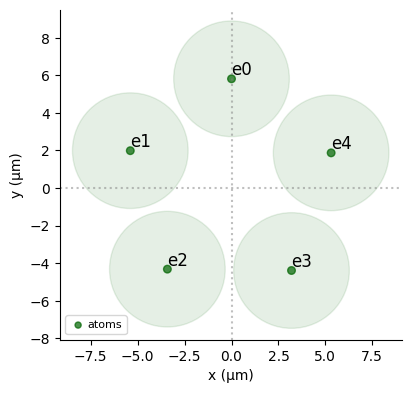

Coordenadas optimizadas:
[[ 3.99442937e-16  5.81627694e+00]
 [-5.39197239e+00  1.98741013e+00]
 [-3.41671561e+00 -4.32384545e+00]
 [ 3.19603307e+00 -4.39554909e+00]
 [ 5.30767948e+00  1.87139092e+00]]


-5391972.389398209 5307679.484181982 -4395549.089580095 5816276.939316845


A=50, B=40.0, C=10.0  →  P(éxito) = 92.30%
  Soluciones válidas: ['00101', '01001', '01010', '10010', '10100']  (E = -180.000)
  Conteos solución:   923 / 1000


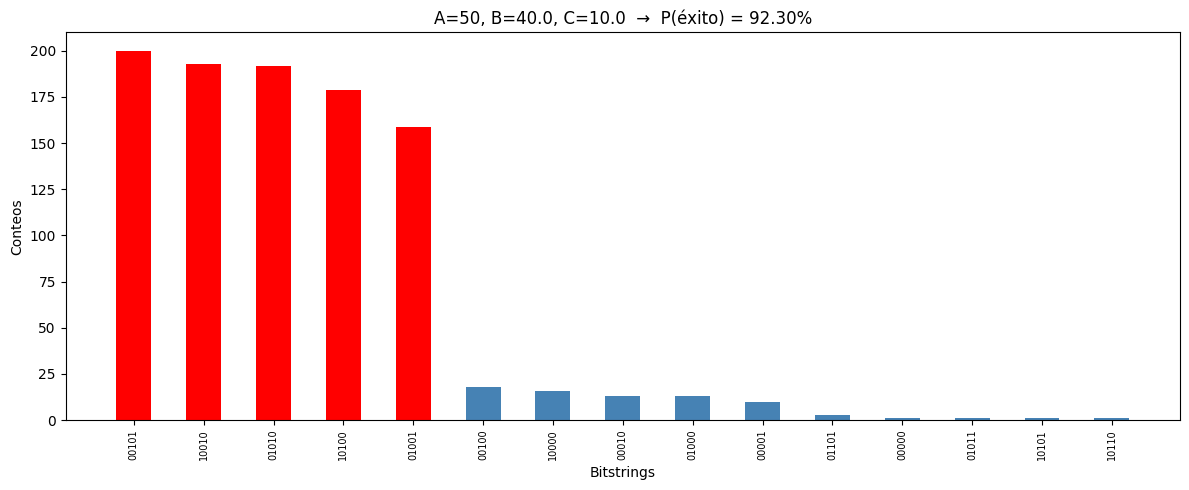

In [59]:
for k in [0.95]:
    A = A_solucion = 50#= 50 #= 10
    B = B_solucion #= k*A_solucion#= 0.4*A_solucion
    C = C_solucion #= 0.2*A_solucion #= 0.2*A_solucion

    sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)

    Q       = Q_func(A, B, C)
    geometria, _       = construir_geometria(Q, plot=True, x0_func=x0_func_C5) #, x0_func=x0_func_P6mod)
    prob, _            = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=True, n_shots=1000)

    A_values = [A]
    B_values = [B]
    C_values = [C]



# Barrido en A para varios grafos

In [54]:
# Barrido en A para varios grafos
# Mantenemos B/A y C/A fijos en valores razonables (Lucas 2014: B/A ~ 0.5, C/A ~ 0.2)

ratio_B = 0.5
ratio_C = 0.2

# Para los grafos a estudiar: {nombre: (Q_func, Q_exacta_func, x0_func)}
# Antes de correr cada grafo, asegurar de tener cargada su celda correspondiente

A_values = np.arange(5, 105, 5)  # 5, 10, ..., 100 rad/µs
n_repeticiones = 3  # Para promediar fluctuaciones estadísticas

resultados_A = {}  # {(grafo, A): [prob_1, prob_2, ...]}
tiempos_A = {}  # {(grafo, A): [t_1, t_2, ...]}

Q_func_g = Q_func
Q_exacta_func_g = Q_exacta_func

grafos = {
    "P4": (Q_func_P4, Q_exacta_func_P4, x0_func_P4),
    "P5": (Q_func_P5, Q_exacta_func_P5, x0_func_P5),
#    "P5 modificado": (Q_func_P5mod, Q_exacta_func_P5mod, x0_func_P5mod),  # Este sale bien pero me da pereza explicarlo
    "P6": (Q_func_P6, Q_exacta_func_P6, x0_func_P6),
#    "P6 modificado": (Q_func_P6mod, Q_exacta_func_P6mod, x0_func_P6mod),  # Este sale con menos probabilidad
    "Y": (Q_func_Y, Q_exacta_func_Y, x0_func_Y_horizontal),
    "C4": (Q_func_C4, Q_exacta_func_C4, x0_func_C4),
    "C5": (Q_func_C5, Q_exacta_func_C5, x0_func_C5),
#    "C_6": (Q_func_C6, Q_exacta_func_C6, x0_func_C6),      # Sale mal por alguna razón
    "K_": (Q_func_K_13, Q_exacta_func_K_13, x0_func_K13),
}



for nombre, (Q_func_g, Q_exacta_func_g, x0_func_g) in grafos.items():
    inicio_grafo = time.time()
    for A in A_values:
        B = ratio_B * A
        C = ratio_C * A
        
        Q = Q_func_g(A, B, C)
        Q_exacta = Q_exacta_func_g(A, B, C)
        
        diag = -np.diag(Q)
        if np.any(diag <= 0):
            resultados_A[(nombre, A)] = [np.nan]
            tiempos_A[(nombre, A)] = [np.nan]
            continue
        
        sort_zipped = resolucion_clasica(Q_exacta)
        
        probs = []
        tiempos = []
        for rep in range(n_repeticiones):
            try:
                t0 = time.time()
                geometria, _ = construir_geometria(Q, seed=rep, plot=False, x0_func=x0_func_g)
                prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C,
                                        plot=False, n_shots=1000)
                t1 = time.time()
                probs.append(prob)
                tiempos.append(t1 - t0)
            except RuntimeError as e:
                print(f"  A={A}, rep={rep}: {e}")
                probs.append(np.nan)
                tiempos.append(np.nan)
        
        resultados_A[(nombre, A)] = probs
        tiempos_A[(nombre, A)] = tiempos

    fin_grafo = time.time()
    print(f"\n=== El grafo {nombre} ha tardado en ejecutarse {fin_grafo - inicio_grafo:.2f} segundos ===")


=== El grafo P4 ha tardado en ejecutarse 10.24 segundos ===

=== El grafo P5 ha tardado en ejecutarse 15.82 segundos ===

=== El grafo P6 ha tardado en ejecutarse 26.29 segundos ===

=== El grafo Y ha tardado en ejecutarse 27.16 segundos ===

=== El grafo C4 ha tardado en ejecutarse 26.54 segundos ===

=== El grafo C5 ha tardado en ejecutarse 26.08 segundos ===

=== El grafo K_ ha tardado en ejecutarse 19.54 segundos ===


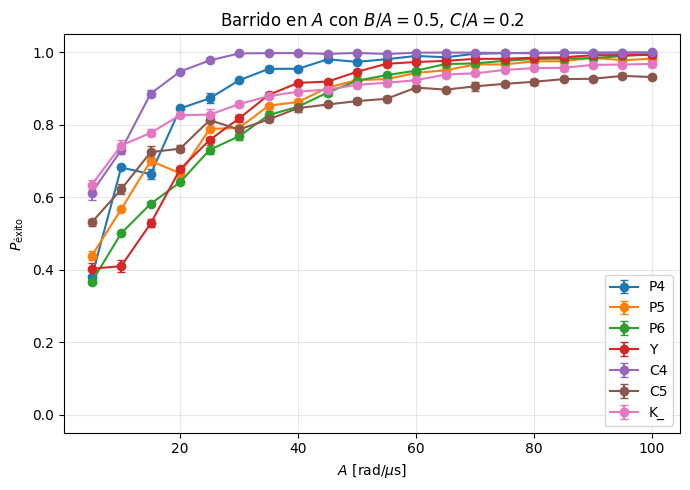

In [56]:
plt.figure(figsize=(7, 5))
for nombre in grafos.keys():
    medias = [np.nanmean(resultados_A[(nombre, A)]) for A in A_values]
    stds   = [np.nanstd(resultados_A[(nombre, A)])  for A in A_values]
    plt.errorbar(A_values, medias, yerr=stds, marker='o', label=nombre, capsize=3)

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel(r'$P_\text{éxito}$')
plt.title(rf'Barrido en $A$ con $B/A={ratio_B}$, $C/A={ratio_C}$')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig("barrido_A.png", dpi=200, bbox_inches='tight')
plt.show()

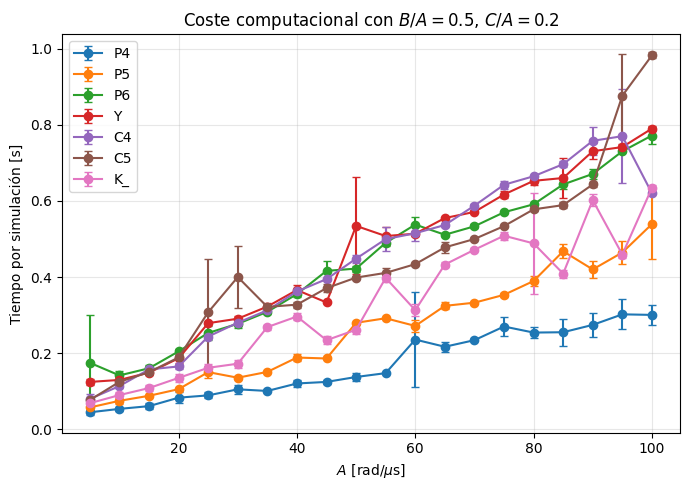

In [57]:
plt.figure(figsize=(7, 5))
for nombre in grafos.keys():
    medias = [np.nanmean(tiempos_A[(nombre, A)]) for A in A_values]
    stds   = [np.nanstd(tiempos_A[(nombre, A)])  for A in A_values]
    plt.errorbar(A_values, medias, yerr=stds, marker='o', label=nombre, capsize=3)

plt.xlabel(r'$A$ [rad/$\mu$s]')
plt.ylabel('Tiempo por simulación [s]')
plt.title(rf'Coste computacional con $B/A={ratio_B}$, $C/A={ratio_C}$')
plt.legend()
plt.grid(alpha=0.3)
#plt.yscale('log')  # Recomendado: el coste crece rápido con A (rigidez del solver)
plt.tight_layout()
plt.savefig("barrido_A_tiempos.png", dpi=200, bbox_inches='tight')
plt.show()

# Heatmap variación B,C

---Solución clásica: 
 [('00101', np.float64(-180.0)), ('01001', np.float64(-180.0)), ('01010', np.float64(-180.0)), ('10010', np.float64(-180.0)), ('10100', np.float64(-180.0)), ('01011', np.float64(-120.0))] 

A=5: 37.18 s


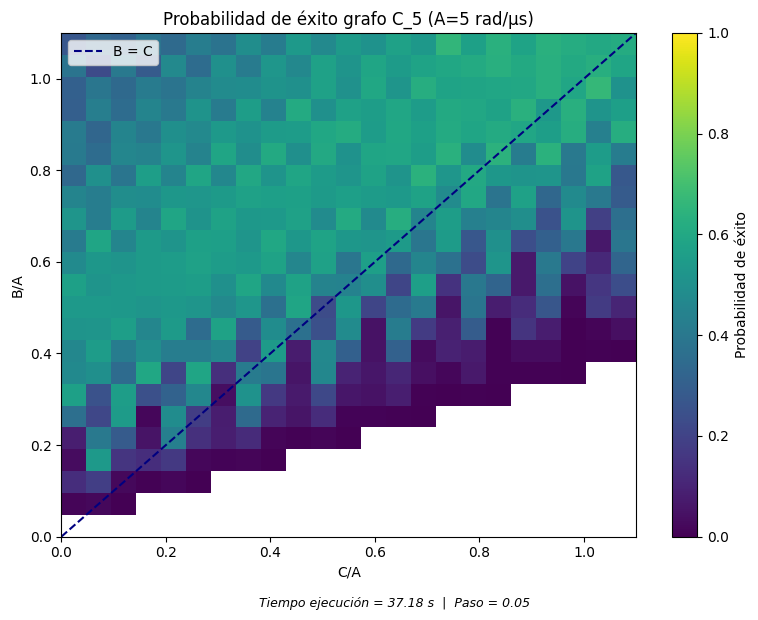

A=20: 91.16 s


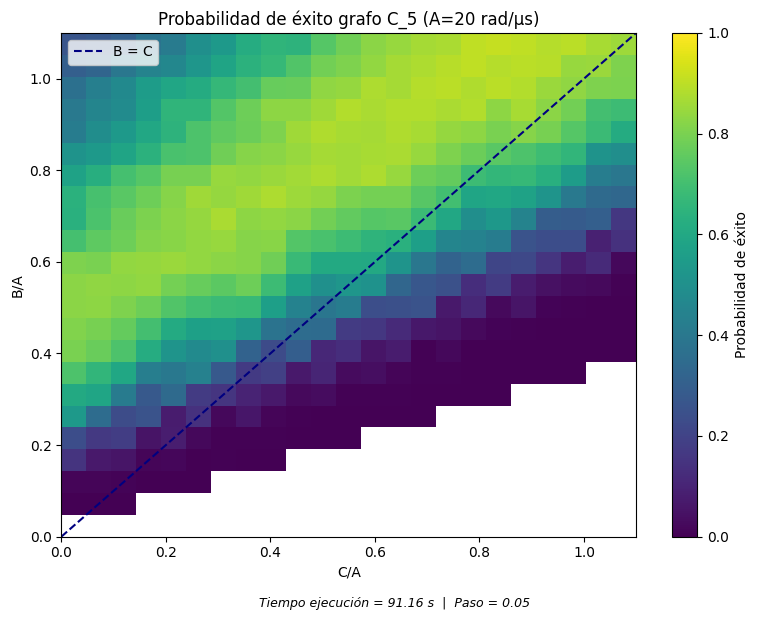

A=50: 192.01 s


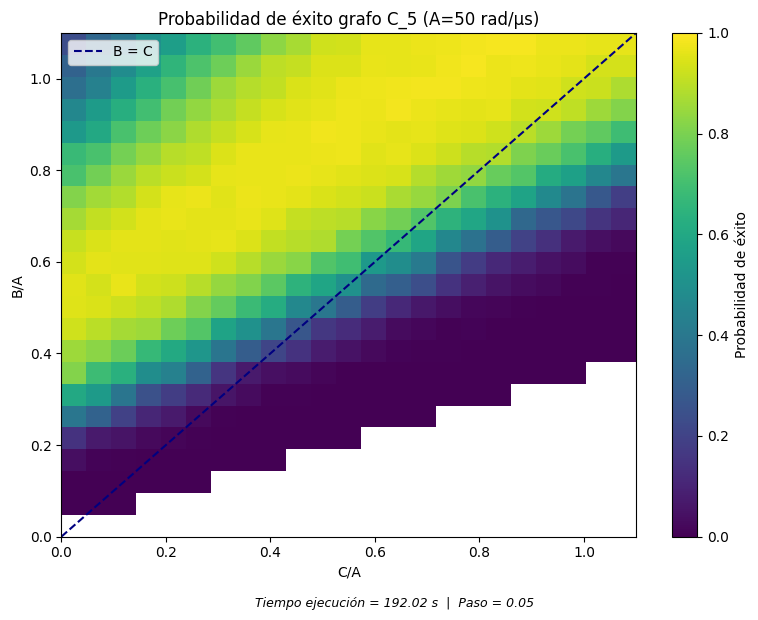

A=100: 344.97 s


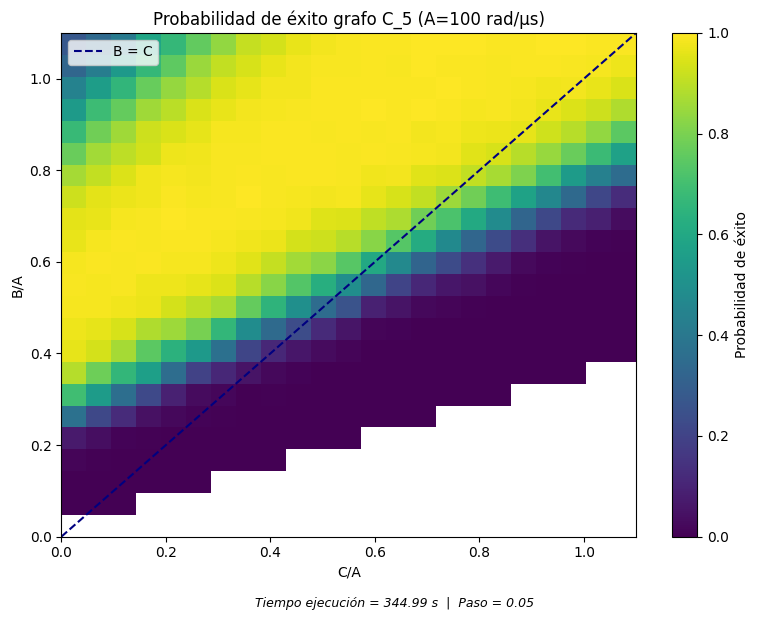

In [63]:
A = A_solucion #10
B = B_solucion #0.5*A
C = C_solucion #0.8*B
sort_zipped = resolucion_clasica(Q_exacta = Q_exacta_func(A_solucion, B_solucion, C_solucion), print_resultados=True)



A_values = [5, 20, 50, 100]
#A_values = np.arange(5, 5.1, 0.5)

resultados = {}
# He cambiado a continuación A por n_shots. Antes tenía n_shots=1000
for A in A_values:
    #B_values = np.arange(0.37*A, 0.42*A, 0.02*A)
    #C_values = np.arange(0.01*A, 0.5*A, 0.02*A)
    #    
    #B_values = np.arange(0.01*A, 1.12*A, 0.08*A)
    #C_values = np.arange(0.01*A, 1.12*A, 0.08*A)

    paso = 0.05
    B_values = np.arange(0*A, 1.12*A, paso*A)
    C_values = np.arange(0*A, 1.12*A, paso*A)

    t0 = time.time() # Para medir el tiempo de ejecución

    for B in B_values:
        for C in C_values:
            Q = Q_func(A, B, C)
            diag = -np.diag(Q)
            
            # Filtro para evitar casos no físicos (detuning negativo)
            if np.any(diag <= 0):
                resultados[(A, B, C)] = np.nan
                continue

            geometria, _ = construir_geometria(Q, plot=False, x0_func=x0_func_C5)
            prob, _ = resolver_qubo(Q, geometria, sort_zipped, A, B, C, plot=False, n_shots=1000)
            resultados[(A, B, C)] = prob



    B_unique = sorted(set(k[1] for k in resultados if k[0] == A))
    C_unique = sorted(set(k[2] for k in resultados if k[0] == A))
    malla = np.array([[resultados[(A, B, C)] for C in C_unique] for B in B_unique])
    malla_masked = np.ma.masked_invalid(malla)

    # Normalizar: B/A y C/B_ref (donde B_ref = 0.5*A como en la definición inicial)
    B_norm = [b / A for b in B_unique]
    C_norm = [c / A for c in C_unique] 

    print(f"A={A}: {time.time() - t0:.2f} s") # Para medir el tiempo de ejecución

    plt.figure(figsize=(8, 6))
    plt.imshow(malla_masked, origin='lower', aspect='auto',
               extent=[C_norm[0], C_norm[-1], B_norm[0], B_norm[-1]], #Esto define los límites de los ejes 
               vmin=0, vmax=1)
    plt.colorbar(label='Probabilidad de éxito')
    plt.xlabel('C/A')
    plt.ylabel('B/A')
    plt.title(f'Probabilidad de éxito grafo {nombre_grafo} (A={A} rad/µs)')

    # Línea B = C (en unidades normalizadas B/A = C/A)
    x_line = np.linspace(C_norm[0], C_norm[-1], 100)
    plt.plot(x_line, x_line, color='navy', linestyle='--', linewidth=1.5, label='B = C')
    plt.figtext(0.5, -0.02,
            f"Tiempo ejecución = {time.time() - t0:.2f} s  |  Paso = {paso:.2f}",
            ha='center', fontsize=9, style='italic')
    plt.legend()
    #plt.savefig(f"mapa_exito_{nombre_grafo} A_{A:.1f}.png")

    plt.tight_layout()
    plt.show()